This notebook runs **normative modeling** of **functional connectivity** data, both **static** and **dynamic**, as a function of **age**. This enables the build of **normative charts of functional connectivity in healthy aging**, embracing both diversity and uncertainty from a cohort of 1000 healthy subjects. A battery of models (statistical frameorks) are fitted to the empirical data through Hierarchical Bayesian Regression proposed in the package Predictive Clinical Neuroscience toolkit (pcntoolkit, https://pcntoolkit.readthedocs.io/en/latest/). The trade-off between predictive power and complexity of the models is assessed through bayesian model comparison, guiding for the choice of an adequate normative model describing this empirical data of functional connectivity. 

In [1]:
import warnings
#removing annoying warnings related to pymc dependencies in pcntoolkit 
warnings.filterwarnings("ignore", category=FutureWarning)

import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize':14, 'axes.titlesize':16})
import pickle
import pcntoolkit as ptk  
import arviz as az
from itertools import product


from funcs import *

## Loading the data

Here a .json containing demographic data of subjects and their FC and FCD (FC dynamics, time-varying) matrices computed from BOLD FMRI recordings.

In [2]:
cwd = os.getcwd()

In [3]:
fc_df = pd.read_json('FUNC_df.json')

In [4]:
fc_df.isna().sum()

SubjectID    0
Age          1
FC           0
FCD          0
dtype: int64

In [5]:
fc_df = fc_df.dropna()
fc_df['FC'] = fc_df['FC'].apply(np.array)
fc_df['FCD'] = fc_df['FCD'].apply(lambda x : np.array(x, dtype='float64'))

In [6]:
fc_df['Mean_FC'] = fc_df['FC'].apply(np.mean)
fc_df['Var_FC'] = fc_df['FC'].apply(np.var)
fc_df['Mean_triuFC'] = fc_df['FC'].apply(lambda x: np.mean(x[np.triu_indices_from(x, k=30)]))
fc_df['Var_triuFC'] = fc_df['FC'].apply(lambda x: np.var(x[np.triu_indices_from(x, k=30)]))

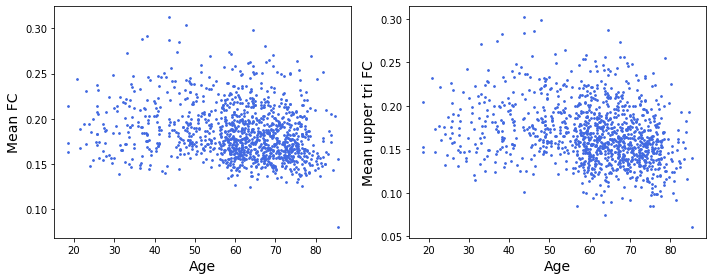

In [7]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), sharex=True)
ax[0].scatter(fc_df['Age'], fc_df['Mean_FC'], s=3, color='royalblue') ; ax[0].set(ylabel='Mean FC')
ax[1].scatter(fc_df['Age'], fc_df['Mean_triuFC'], s=3, color='royalblue') ; ax[1].set(ylabel='Mean upper tri FC')
for a in ax.flatten() :
    a.set_xlabel('Age')
fig.tight_layout()
plt.show()

In [6]:
for i in range(1000) :
    test = np.isnan(fc_df['FCD'].iloc[i]).sum()
    if test > 0 :
        print(i)

51
578
672


In [8]:
fc_df['Mean_FCD'] = fc_df['FCD'].apply(np.nanmean)
fc_df['Var_FCD'] = fc_df['FCD'].apply(np.nanvar)
fc_df['Mean_triuFCD'] = fc_df['FCD'].apply(lambda x: np.nanmean(x[np.triu_indices_from(x, k=30)]))
fc_df['Var_triuFCD'] = fc_df['FCD'].apply(lambda x: np.nanvar(x[np.triu_indices_from(x, k=30)]))

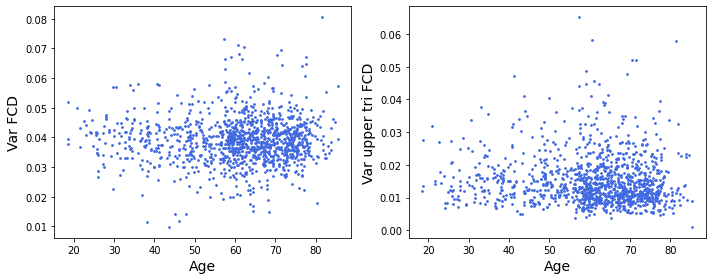

In [9]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), sharex=True)
ax[0].scatter(fc_df['Age'], fc_df['Var_FCD'], s=3, color='royalblue') ; ax[0].set(ylabel='Var FCD')
ax[1].scatter(fc_df['Age'], fc_df['Var_triuFCD'], s=3, color='royalblue') ; ax[1].set(ylabel='Var upper tri FCD')
for a in ax.flatten() :
    a.set_xlabel('Age')
fig.tight_layout()
plt.show()

# 1. Modeling normative charts of average FC through Aging

We will perform hierarchical bayesian regression of the response "Mean_FC" (subject-specific) on the predictor or covariate "Age".

In [10]:
x_str = 'Age' ; y_str = 'Mean_FC'

In [11]:
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

## 1.1 Linear models

Linear models assume linear effects on covariates ($x$), of the form $\beta_0 + \beta_1 x$. Classical linear regression models observation $y$ as $y = \beta_0 + \beta_1 x + \zeta$ where $\zeta$ is the residual error. Typically, it is assumed that errors are normally distributed, that is: $ \zeta \sim N(0, \sigma)$. The latter makes the regression equivalent to $y \sim N(\beta_0 + \beta_1 x, \sigma)$ which means we assume the response $y$ to be normally distributed around a linear function of the covariate, with a certain dispertion or standard deviation $\sigma$. 

The value of $\sigma$ (to be estimated) can either be assumed to not depend on the covariate values, in this case we say we model with homoscedastic noise, and will estimate only a single value for this parameter. If we assume that the noise varies along with the covariate, for example when we see that the data is more dispersed for some values of the covariate, and more concentrated for others, we say that we assume heteroscedastic noise. Hence, we can put linear effects on the noise parameter, $\sigma \sim N(\alpha_0 + \alpha_1 x, \eta)$.


Linear effects can also be assumed on parameters of higher-order, such as the ones in SHASH (SinH-ArcSinH) distribution. SHASH is a generalization of the normal distribution. While the normal distribution is symmetric and has light to moderate tails and can be defined by just two parameters (location (mean) and scale or (standard deviation)), the SHASH distribution has two more parameters which control asymmetry and tail weight. See (https://statisticaloddsandends.wordpress.com/2019/04/15/the-sinh-arcsinh-normal-distribution/).
In the PCNtoolkit architecture, the asymetry parameter is denoted $\epsilon$ and the tail weight is $\delta$. When $\epsilon=0$ and $\delta=1$, it is equivalent to the normal distribution.

Here we will try to fit the data with different models, assuming always linear effects on the mean, but trying without and with linear effects on the other parameters $\sigma$, $\epsilon$ and $\delta$.

We will try the following models:

* "lin_hom" : $y \sim N(\mu,\sigma), \mu = \beta x$,
* "lin_het": $y \sim N(\mu,\sigma), \mu = \beta_{1}x, \sigma = \beta_{2}x$
* "lin_shash_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x$ 
* "lin_shash_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$
* "lin_shash_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$
* "lin_shash_all" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$

Note that pcntoolkit assumes by default linear effects on the mean but not on the other parameter(s), and Normal distribution for the likelihood.

In [12]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               }, 
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
There were 374 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sigma, y_like]


Output()

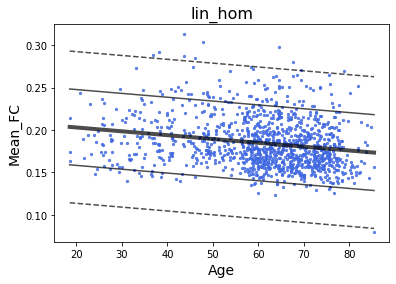

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Sampling: [y_like]


Output()

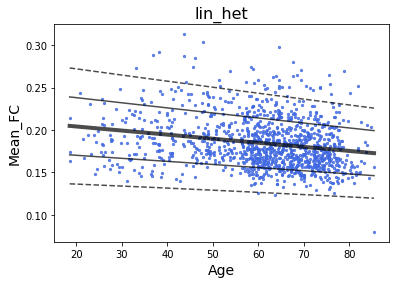

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.
Sampling: [y_like]


Output()

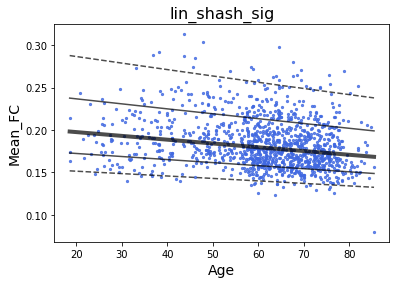

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.
Sampling: [y_like]


Output()

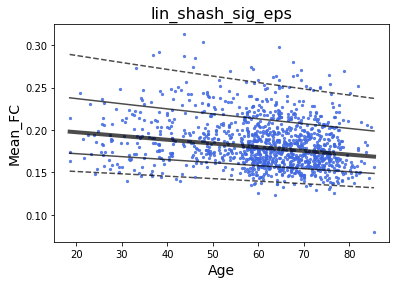

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
Sampling: [y_like]


Output()

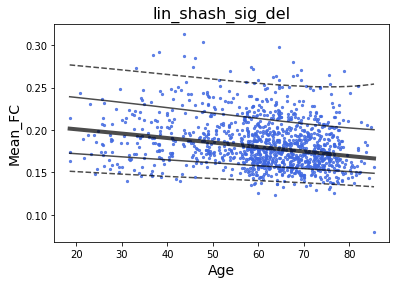

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 32 seconds.
Sampling: [y_like]


Output()

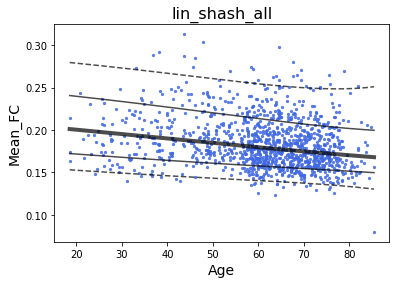

In [13]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(fc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, fc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Note that the linear regression with no variation of the noise (lin_hom) raises numerous divergences in HMC sampling, which indicates this model is not adapted to the data at hand.

## 1.2 Non-linear (b-splines) models

Now, instead of assuming linear effects on model parameters, we will assume a more complex relashionship linking the covariate to the observations. Instead of the linear relashionship of the form $\beta_0 + \beta_1 x$, we will assume a non-linear function of the covariate $f(x)$, in the form of a B-spline (https://en.wikipedia.org/wiki/B-spline). For doing this, we pass as an argument model_type='bspline'. This type of models are called Generalized Additive Models (GAM). When GAM are used with higher order (shape) parameters, they are called GAMLSS [1].

Again, we will try the following models:

* "gam_hom" : $y \sim N(\mu,\sigma), \mu = f(x)$
* "gam_het" : $y \sim N(\mu,\sigma), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig_eps" $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$
* "gamlss_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$
* "gamlss_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$
             
          
             
[1] R. A. Rigby, D. M. Stasinopoulos, Generalized Additive Models for Location, Scale and Shape, Journal of the Royal Statistical Society Series C: Applied Statistics, Volume 54, Issue 3, June 2005, Pages 507–554, https://doi.org/10.1111/j.1467-9876.2005.00510.x

In [14]:
models_name = ['gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 81 seconds.
There were 232 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sigma, y_like]


Output()

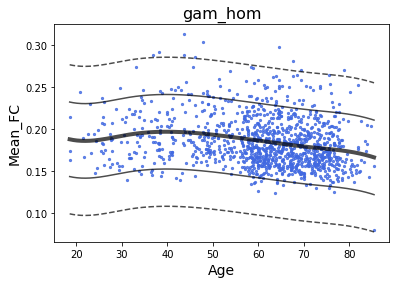

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 95 seconds.
Sampling: [y_like]


Output()

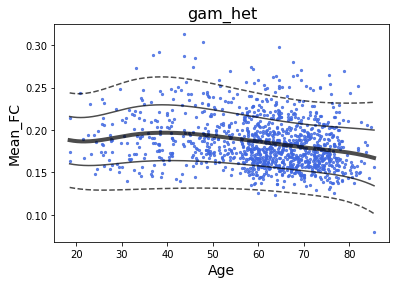

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 308 seconds.
Sampling: [y_like]


Output()

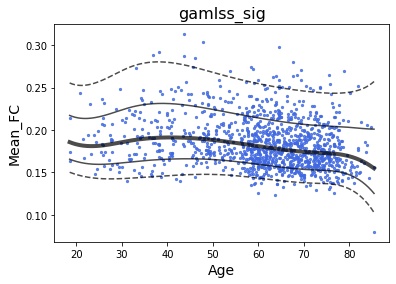

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 336 seconds.
Sampling: [y_like]


Output()

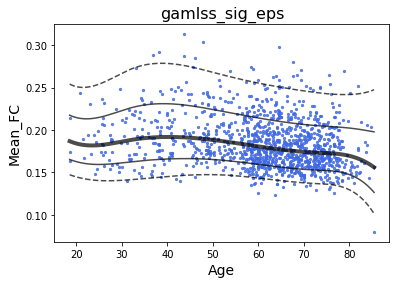

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 338 seconds.
Sampling: [y_like]


Output()

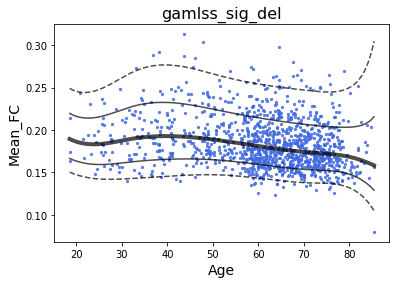

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Mean_FC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 374 seconds.
Sampling: [y_like]


Output()

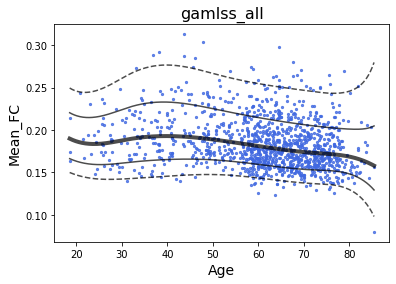

In [15]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(fc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      model_type='bspline',
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, fc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Again, the model with homoscedastic noise raises numerous divergences. Indeed, one can directly see from the data that the dispersion of the observations is not the same accross the age. 

### How to load models if necessary

In [16]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all',
               'gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')
 
x_str = 'Age' ; y_str = 'Mean_FC'
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

for name in models_name :
    with open("./reg_fits/x=" + x_str + "_y=" + y_str + "_fit_" + name + ".pkl",'rb') as file :
        nm = pickle.load(file)
    models_dict['name'].append(name)
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

## 1.3 Model comparison

The trade-off between predictive power and complexity of the models is assessed through bayesian model comparison, guiding for the choice of an adequate normative model describing this empirical data of structural connectivity.
The model comparison will be based on the estimated log predictive density (elpd) of the models. For that, we need the pointwise log likelihood, that is the log likelihood at each data point.

In [18]:
for i in range(len(models_dict['name'])) :
    nm, inscaler = models_dict['object'][i], models_dict['inscaler'][i]
    #way i found to sample from posterior predictive
    #nm.hbr.idata object is actualized
    nm.get_mcmc_quantiles(inscaler.fit_transform(fc_df[x_str]))

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

In [19]:
models_dict['loglik'] = []
for i in range(len(models_dict['name'])) :
    nm, outscaler = models_dict['object'][i], models_dict['outscaler'][i]
    samples = nm.hbr.idata.posterior_predictive
    loglik = compute_loglikelihood(nm, samples, outscaler.fit_transform(fc_df[y_str]))
    models_dict['loglik'].append(loglik)

/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)


In [20]:
sum_loglik = []
for l in models_dict['loglik'] :
    sum_loglik.append(np.nanmean(l, axis=(0, 1)).sum())
sum_loglik 

[-inf,
 -1641.1366235299529,
 -1574.780611478621,
 -1577.0772014036875,
 -1580.559920301641,
 -1583.6226672252924,
 -inf,
 -1633.338751130473,
 -1549.8085425887539,
 -1551.2855828501924,
 -1556.775382992329,
 -1562.6143056775509]

For the models with homoscedastic noise, the likelihood is so low in some datapoints that it raises the log likelihood to -infinity. Indeed, these models are disqualified from the comparison, as they are clearly not adapted.

In [21]:
nm_idata_list = []
for i in range(len(models_dict['object'])) :
    nm_idata_list.append(models_dict['object'][i].hbr.idata.copy())
    nm_idata_list[-1].add_groups(log_likelihood={"log_lik": models_dict['loglik'][i]})

In [22]:
models_data_dict = {m: d for m, d in zip(models_dict['name'], nm_idata_list)}
compare = az.compare(models_data_dict)
compare

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a mo

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
gamlss_sig,0,-1564.118886,26.038282,0.000000,0.083333,29.368812,0.000000,True,log
gamlss_sig_eps,1,-1566.617464,27.655827,2.498577,0.083333,29.934119,1.149283,True,log
gamlss_sig_del,2,-1576.145085,34.365202,12.026199,0.083333,30.021371,5.227255,True,log
gamlss_all,3,-1582.560253,35.647270,18.441367,0.083333,29.866123,5.202914,True,log
lin_shash_sig,4,-1583.495291,16.721046,19.376405,0.083333,35.767176,11.447001,True,log
lin_shash_sig_eps,5,-1589.684590,22.545467,25.565703,0.083333,37.172004,13.410242,True,log
lin_shash_sig_del,6,-1593.433795,24.005143,29.314909,0.083333,36.374894,14.128506,True,log
lin_shash_all,7,-1598.841628,28.009305,34.722741,0.083333,34.972867,12.685513,True,log
gam_het,8,-1639.059446,10.955135,74.940559,0.083333,28.714844,13.302693,False,log
lin_het,9,-1643.639270,4.922309,79.520384,0.083333,29.064395,13.604523,False,log


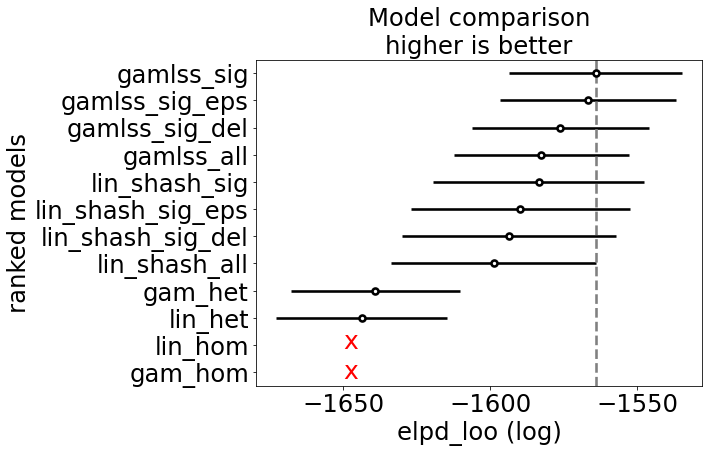

In [24]:
fig, ax = plt.subplots(1, figsize=(8, 6))
az.plot_compare(compare, ax=ax) 
ax.text(-1650, -1.02, s='x', size=25, color='red')
ax.text(-1650, -0.92, s='x', size=25, color='red');

Model comparison is to be interpeted with caution, as multiple warnings have been raised during computation, indicating that the findings might not be reliable. The two worst-performing models (lin_hom and gam_hom) are not adapted because they cannot take into account the heterogeneous distribution of noise with respect to age. Other than that, we can clearly see that the higher-order parameters informing the shape (eg. asymetry) of the model distribution are adding information and increasing the predictive power, which is also done by the use of non-linear functions. 

## 1.4 Summary

Finally, we plot the normative charts (quantiles of the estimated normative models) of average FC values with respect to age, for all the models we have tried. We indicate their rank based on model comparison, keeping in mind that only the models with homoscedastic noise are "bad" models.

In [25]:
subtitles = [r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta x$',
             r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f(x)$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$']

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Text(1, 0.2, 'Non-linear')

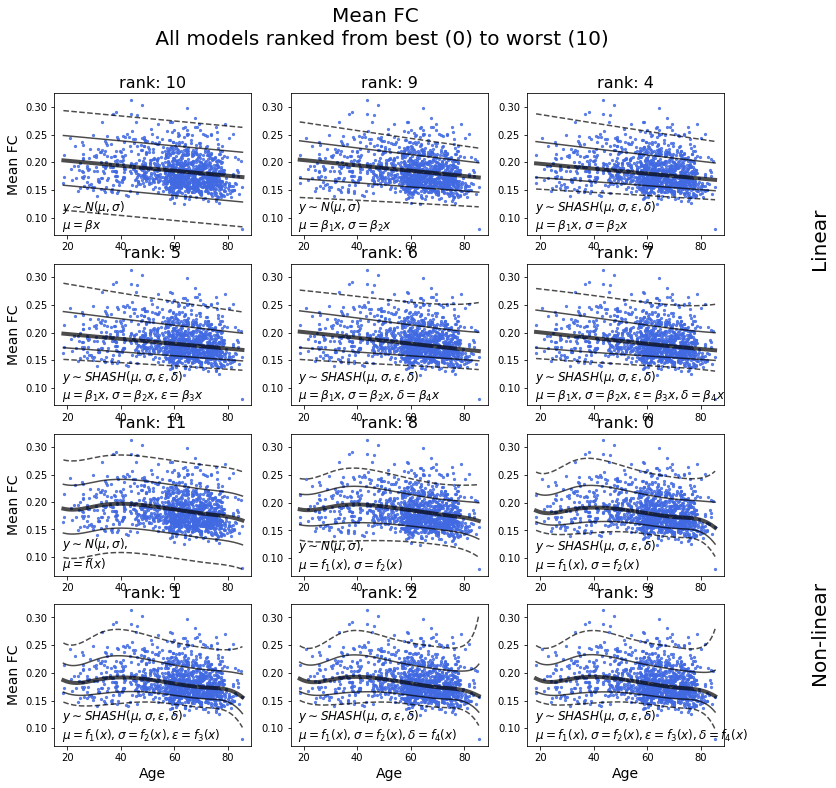

In [33]:
fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(12, 12))
    
for i in range(len(models_dict['name'])) :
    plot_quantiles(models_dict['object'][i], 
                   fc_df, 
                   x_str, 
                   y_str, 
                   models_dict['inscaler'][i], 
                   models_dict['outscaler'][i], 
                   n_qs=2,
                   ax=ax[i//3, i%3])
    ax[i//3, i%3].set_title('rank: ' + str(compare['rank'][models_dict['name']][i]), size=16)
    ax[i//3, i%3].set_xlabel('')
    ax[i//3, i%3].set_ylabel('')
    if i%3 == 0 :
        ax[i//3, i%3].set_ylabel('Mean FC')
    if i//3 == 3 :
        ax[i//3, i%3].set_xlabel('Age')
    ax[i//3, i%3].text(18, 0.08, s=subtitles[i], size=12)

fig.suptitle('Mean FC \n All models ranked from best (0) to worst (10)', size=20)
fig.text(1, 0.68, 'Linear', rotation=90, size=20)
fig.text(1, 0.2, 'Non-linear', rotation=90, size=20)

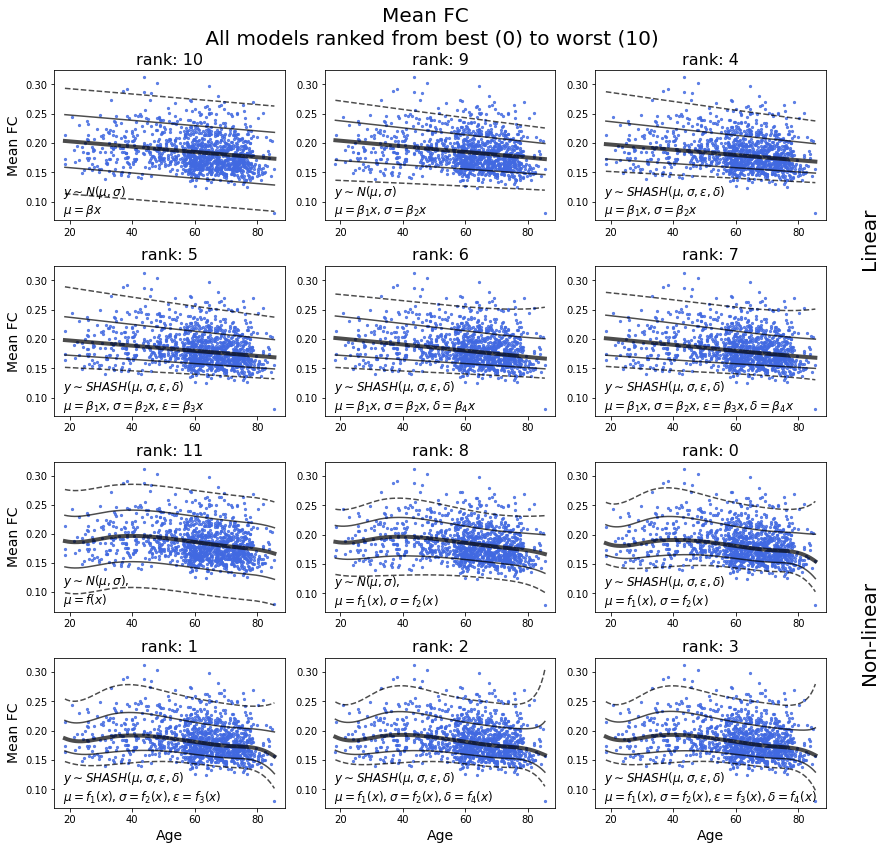

In [34]:
fig.tight_layout()
fig

# 2. Modeling normative charts of variance of FCD through Aging

We will perform the same pipeline, this time with the variance of the upper triangular part of time-variying, dynamiuc FC (FCD).

In [10]:
x_str = 'Age' ; y_str = 'Var_triuFCD'

In [11]:
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

## 2.1 Linear models
* "lin_hom" : $y \sim N(\mu,\sigma), \mu = \beta x$,
* "lin_het": $y \sim N(\mu,\sigma), \mu = \beta_{1}x, \sigma = \beta_{2}x$
* "lin_shash_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x$ 
* "lin_shash_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$
* "lin_shash_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$
* "lin_shash_all" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$

In [12]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               }, 
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
There were 359 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sigma, y_like]


Output()

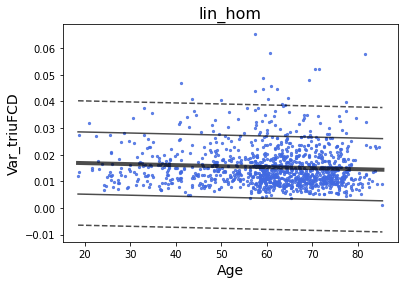

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
Sampling: [y_like]


Output()

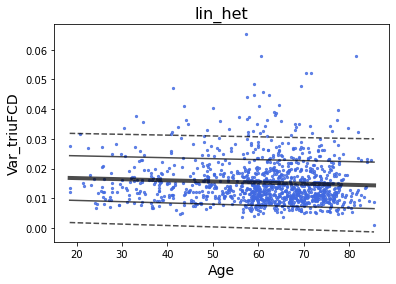

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.
Sampling: [y_like]


Output()

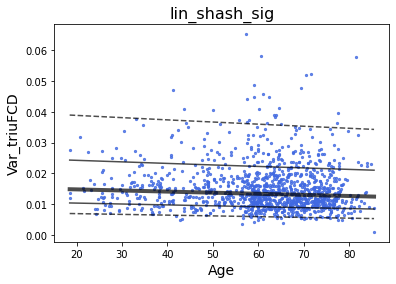

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.
Sampling: [y_like]


Output()

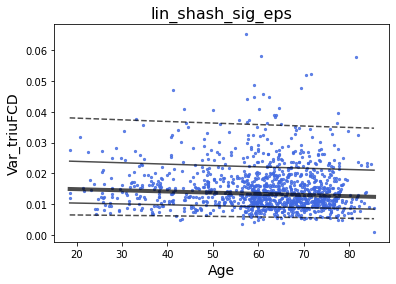

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.
Sampling: [y_like]


Output()

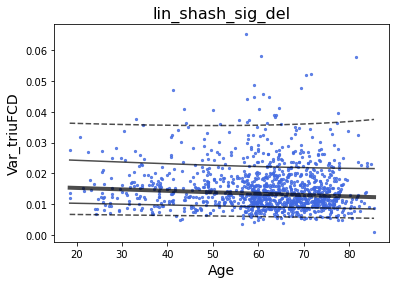

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.
Sampling: [y_like]


Output()

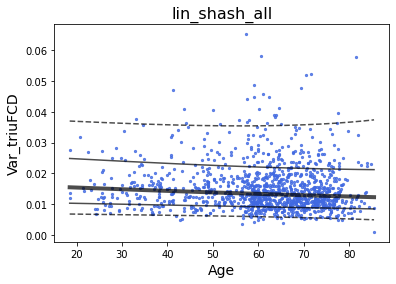

In [13]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(fc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, fc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Here again, divergences in the homoscedastic case

## 2.2 Non-linear (b-splines) models

* "gam_hom" : $y \sim N(\mu,\sigma), \mu = f(x)$
* "gam_het" : $y \sim N(\mu,\sigma), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig_eps" $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$
* "gamlss_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$
* "gamlss_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$
             
          

In [14]:
models_name = ['gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

models_args = [{}, 
               {
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_delta':'True'
               },
               {
                   'likelihood':'SHASHo2', 
                   'linear_sigma':'True', 
                   'linear_epsilon':'True',
                   'linear_delta':'True'
               }]

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 76 seconds.
There were 33 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [sigma, y_like]


Output()

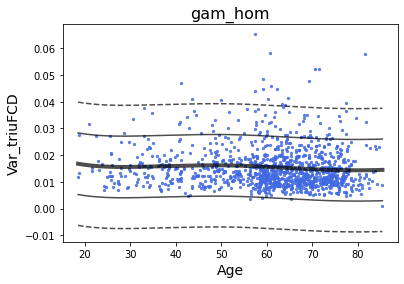

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 95 seconds.
Sampling: [y_like]


Output()

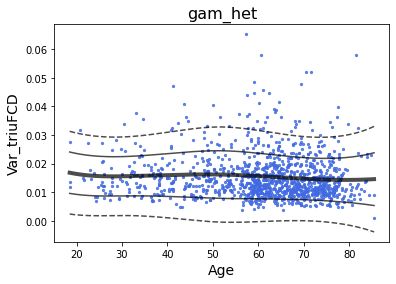

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 395 seconds.
Sampling: [y_like]


Output()

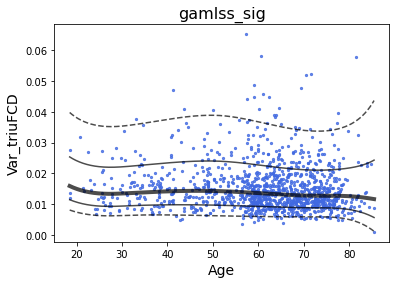

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 416 seconds.
Sampling: [y_like]


Output()

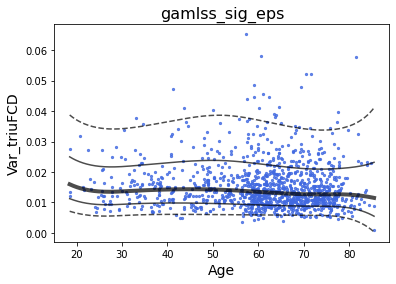

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 431 seconds.
Sampling: [y_like]


Output()

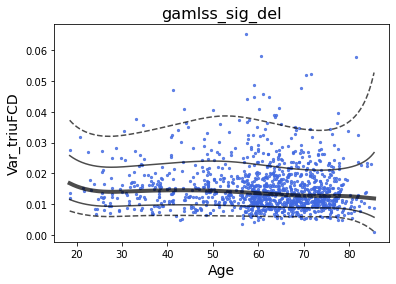

Processing data in /mnt/data/tng/phd/1000brains/Pseudo/regression/reg_data/Var_triuFCD.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 444 seconds.
Sampling: [y_like]


Output()

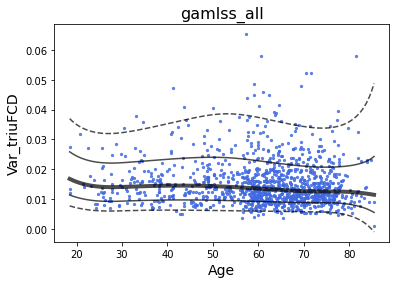

In [15]:
for i_model in range(len(models_name)) :
    
    nm, inscaler, outscaler = hbr_fit(fc_df, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i_model], 
                                      n_chains=4, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      model_type='bspline',
                                      **models_args[i_model])
    
    models_dict['name'].append(models_name[i_model])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

    ax = plot_quantiles(nm, fc_df, x_str, y_str, inscaler, outscaler)
    ax.set_title(models_name[i_model])
    plt.show()

Again, divergences for the first model

### How to load models if necessary

In [16]:
models_name = ['lin_hom', 
               'lin_het', 
               'lin_shash_sig', 
               'lin_shash_sig_eps', 
               'lin_shash_sig_del', 
               'lin_shash_all',
               'gam_hom', 
               'gam_het', 
               'gamlss_sig', 
               'gamlss_sig_eps', 
               'gamlss_sig_del', 
               'gamlss_all']

inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')
 
x_str = 'Age' ; y_str = 'Var_triuFCD'
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': []}

for name in models_name :
    with open("./reg_fits/x=" + x_str + "_y=" + y_str + "_fit_" + name + ".pkl",'rb') as file :
        nm = pickle.load(file)
    models_dict['name'].append(name)
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)

## 2.3 Model comparison

In [17]:
for i in range(len(models_dict['name'])) :
    nm, inscaler = models_dict['object'][i], models_dict['inscaler'][i]
    #way i found to sample from posterior predictive
    #nm.hbr.idata object is actualized
    nm.get_mcmc_quantiles(inscaler.fit_transform(fc_df[x_str]))

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

In [18]:
models_dict['loglik'] = []
for i in range(len(models_dict['name'])) :
    nm, outscaler = models_dict['object'][i], models_dict['outscaler'][i]
    samples = nm.hbr.idata.posterior_predictive
    loglik = compute_loglikelihood(nm, samples, outscaler.fit_transform(fc_df[y_str]))
    models_dict['loglik'].append(loglik)

/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/mnt/data/tng/phd/1000brains/Pseudo/regression/funcs.py:182: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)


In [19]:
sum_loglik = []
for l in models_dict['loglik'] :
    sum_loglik.append(np.nanmean(l, axis=(0, 1)).sum())
sum_loglik 

[-inf,
 -1666.5573030454643,
 -1475.109365936748,
 -1484.118814506299,
 -1471.5740165460047,
 -1478.6202536627432,
 -inf,
 -1662.2282814303064,
 -1468.1680238002732,
 -1476.372416650271,
 -1463.9572380930865,
 -1472.3802967356444]

In [20]:
nm_idata_list = []
for i in range(len(models_dict['object'])) :
    nm_idata_list.append(models_dict['object'][i].hbr.idata.copy())
    nm_idata_list[-1].add_groups(log_likelihood={"log_lik": models_dict['loglik'][i]})

In [21]:
models_data_dict = {m: d for m, d in zip(models_dict['name'], nm_idata_list)}
compare = az.compare(models_data_dict)
compare

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/numpy/core/_methods.p

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
lin_shash_sig_del,0,-1481.793210,20.017831,0.000000,0.083333,45.946993,0.000000,False,log
lin_shash_sig,1,-1484.274406,18.037063,2.481197,0.083333,46.119799,2.951884,False,log
gamlss_sig_del,2,-1485.201532,39.421950,3.408322,0.083333,44.788724,4.968255,True,log
gamlss_sig,3,-1487.998959,36.724525,6.205749,0.083333,45.340787,6.052794,True,log
lin_shash_all,4,-1490.323602,22.825046,8.530393,0.083333,46.602522,1.770128,False,log
lin_shash_sig_eps,5,-1494.242374,19.706869,12.449164,0.083333,47.152922,3.195826,False,log
gamlss_all,6,-1497.243826,46.070141,15.450616,0.083333,45.634838,5.755611,True,log
gamlss_sig_eps,7,-1499.534401,42.303503,17.741191,0.083333,46.418824,6.275654,True,log
lin_het,8,-1670.824479,8.212137,189.031269,0.083333,46.755213,28.855572,False,log
gam_het,9,-1672.453343,18.950271,190.660133,0.083333,46.481427,28.768359,True,log


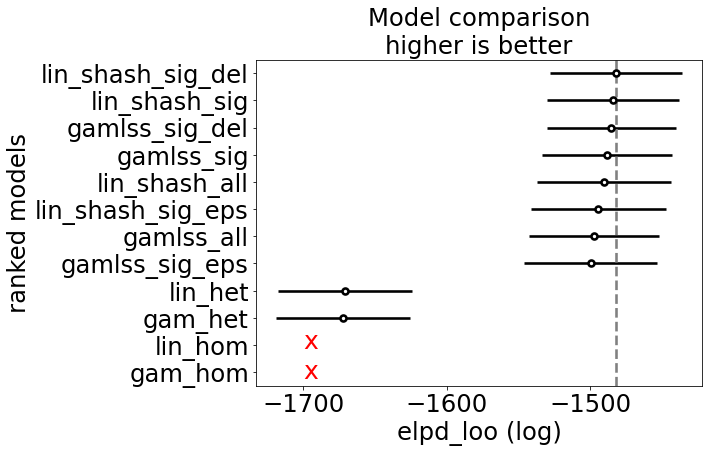

In [25]:
fig, ax = plt.subplots(1, figsize=(8, 6))
az.plot_compare(compare, ax=ax) 
ax.text(-1700, -1.02, s='x', size=25, color='red')
ax.text(-1700, -0.92, s='x', size=25, color='red');

Again, even though we must be cautious since multiple warnings have been raised during computation, we can clearly see that the higher-order parameters informing the shape (eg. asymetry) of the model distribution are adding information and increasing the predictive power, which is also done by the use of non-linear functions. Within this group, the trade-of between predictive power and complexity more or less amounts to the same.

## 2.4 Summary

In [26]:
subtitles = [r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta x$',
             r'$y \sim N(\mu,\sigma)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \epsilon = \beta_{3}x, \delta = \beta_{4}x$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f(x)$',
             r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$',
             r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$']

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Text(1, 0.2, 'Non-linear')

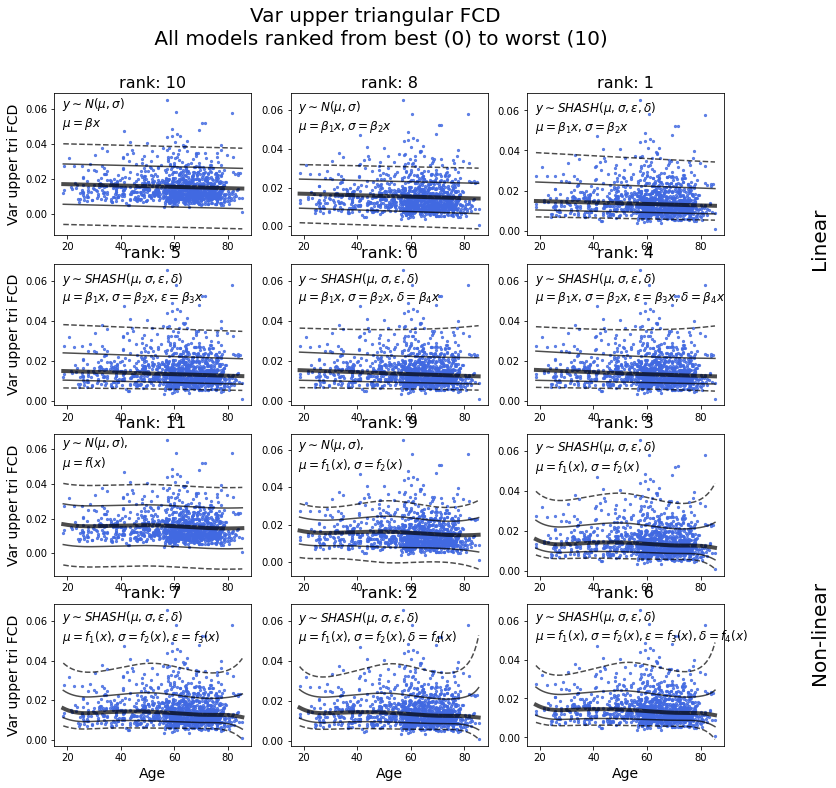

In [27]:
fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(12, 12))
    
for i in range(len(models_dict['name'])) :
    plot_quantiles(models_dict['object'][i], 
                   fc_df, 
                   x_str, 
                   y_str, 
                   models_dict['inscaler'][i], 
                   models_dict['outscaler'][i], 
                   n_qs=2,
                   ax=ax[i//3, i%3])
    ax[i//3, i%3].set_title('rank: ' + str(compare['rank'][models_dict['name']][i]), size=16)
    ax[i//3, i%3].set_xlabel('')
    ax[i//3, i%3].set_ylabel('')
    if i%3 == 0 :
        ax[i//3, i%3].set_ylabel('Var upper tri FCD')
    if i//3 == 3 :
        ax[i//3, i%3].set_xlabel('Age')
    ax[i//3, i%3].text(18, 0.05, s=subtitles[i], size=12)

fig.suptitle('Var upper triangular FCD \n All models ranked from best (0) to worst (10)', size=20)
fig.text(1, 0.68, 'Linear', rotation=90, size=20)
fig.text(1, 0.2, 'Non-linear', rotation=90, size=20)

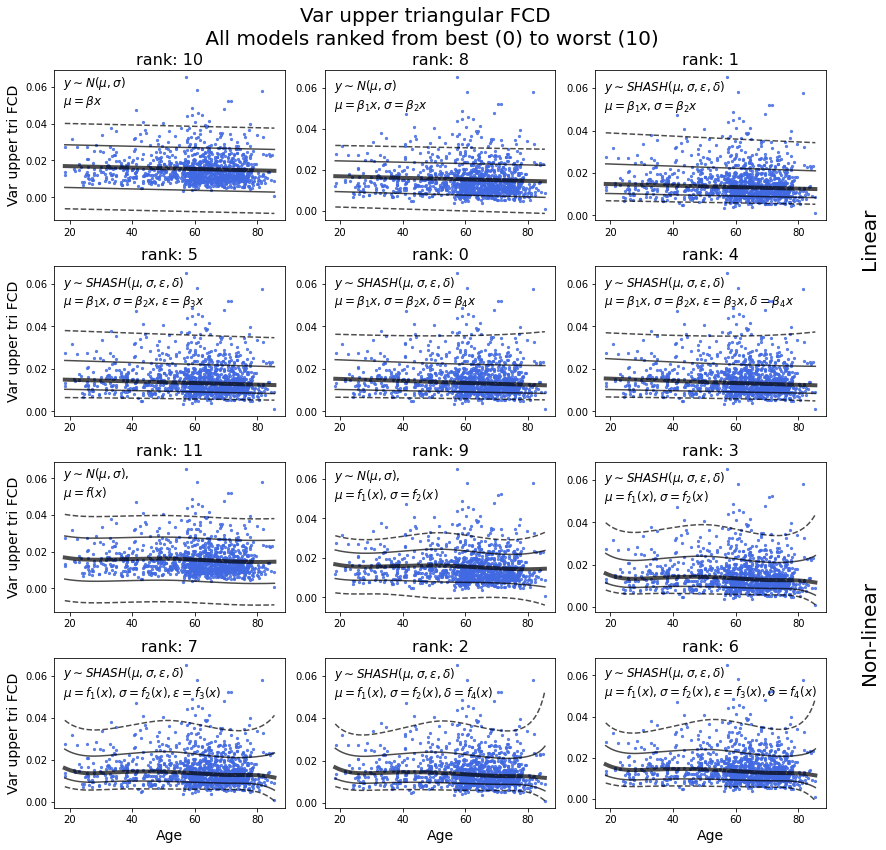

In [28]:
fig.tight_layout()
fig

# 3. Final summary: best fits

We show the "best fits" (according to model comparison) of normative models (with quantiles) for the variance of upper triangular of FC and FC Dynamics (FCD).


The normative charts, learned from the data under guidance of a model, embrace both aleatoric uncertainty (inherent variability) and epistemic uncertainty (for example, lack of data).

In [32]:
with open("./reg_fits/x=Age_y=Mean_FC_fit_gamlss_sig.pkl",'rb') as file :
    reg_Age_Mean_FC = pickle.load(file)
    
with open("./reg_fits/x=Age_y=Var_triuFCD_fit_lin_shash_sig_del.pkl",'rb') as file :
    reg_Age_Var_triuFCD = pickle.load(file)

In [33]:
inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

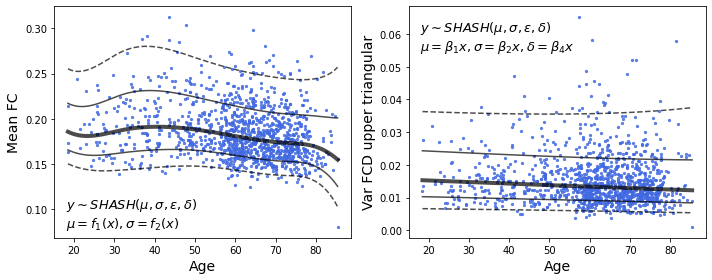

In [39]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
plot_quantiles(reg_Age_Mean_FC, fc_df, 'Age', 'Mean_FC', inscaler, outscaler, n_qs=2, ax=ax[0])
plot_quantiles(reg_Age_Var_triuFCD, fc_df, 'Age', 'Var_triuFCD', inscaler, outscaler, n_qs=2, ax=ax[1])
ax[0].set(ylabel='Mean FC')
ax[1].set(ylabel='Var FCD upper triangular')

ax[0].text(18, 
           0.08, 
           r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
          size=13)

ax[1].text(18, 
           0.055, 
           r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = \beta_{1}x, \sigma = \beta_{2}x, \delta = \beta_{4}x$',
          size=13)

fig.tight_layout()

# Packages info

In [2]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri Dec 20 2024

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.34.0

pcntoolkit: 0.29.post1
arviz     : 0.20.0
numpy     : 1.26.4
matplotlib: 3.9.2
pandas    : 2.2.3
logging   : 0.5.1.2

Watermark: 2.4.3

